# K-Means Clustering Algorithm

## Introduction

K-Means is an **unsupervised learning** algorithm used to group similar data points into **K clusters**. It partitions the dataset such that points within the same cluster are more similar to each other than to points in other clusters.

For example, students can be clustered based on **GPA** and **IQ** (2-dimensional data), although K-Means works for **n-dimensional** data as well.

---

## Algorithm

### Step 1: Choose the Number of Clusters

- Decide the number of clusters, **K**.

### Step 2: Initialize Centroids

- Randomly initialize **K centroids**.

### Step 3: Assign Data Points to Clusters

- Compute the **Euclidean distance** between each data point and every centroid.

[Write formula]

- Assign each data point to the cluster whose centroid has the **minimum Euclidean distance**.

### Step 4: Update Centroids

- Compute the **mean** of all data points assigned to each cluster.
- The computed mean becomes the **new centroid**.

[Write formula]

### Step 5: Repeat Until Convergence

- Repeat **Steps 3 and 4** until the centroids no longer change (or change negligibly).

---

## Choosing the Number of Clusters (Elbow Method)

The **Elbow Method** helps determine the optimal value of **K**.

### Within-Cluster Sum of Squares (WCSS)

WCSS (also called **Inertia**) measures the compactness of clusters.

$$
\text{WCSS}=\sum_{i=1}^{K}\sum_{x_j \in C_i}\|x_j-\mu_i\|^2
$$

where:

- $K$ = number of clusters
- $C_i$ = set of points in cluster $i$
- $\mu_i$ = centroid of cluster $i$

### Procedure

1. Run K-Means for different values of **K** (typically 1 to 10 or 20).
2. Compute the WCSS for each value of **K**.
3. Plot **Number of Clusters (K)** vs **WCSS**.

Since adding more clusters reduces the distance to the centroids,

$$
\text{WCSS}_1 > \text{WCSS}_2 > \text{WCSS}_3 > \cdots
$$

always holds.

![](./images/img1.png)

### Selecting K

- Choose the **elbow point**, where the decrease in WCSS begins to level off.
- Beyond this point, increasing the number of clusters provides only marginal improvement.

---

## Mathematical Formulas

### Euclidean Distance

$$
d(\mathbf{x}, \mathbf{\mu})=\sqrt{\sum_{i=1}^{n}(x_i-\mu_i)^2}
$$

### Centroid Update

For a cluster containing $m$ points,

$$
\mathbf{\mu}=\frac{1}{m}\sum_{i=1}^{m}\mathbf{x}_i
$$

# Practical Example

In [1]:
import pandas as pd 
import numpy as np

In [3]:
df = pd.read_csv("./dataset/student_clustering.csv")
df.head()

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


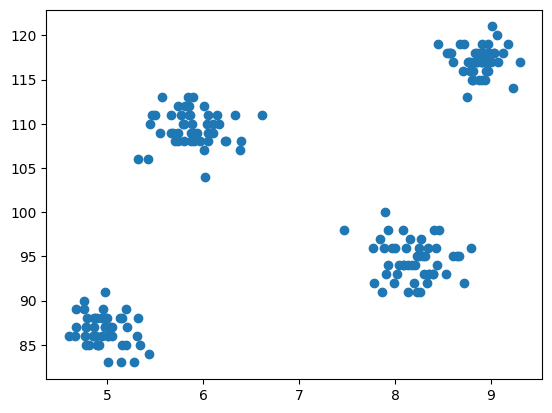

In [4]:
import matplotlib.pyplot as plt
plt.scatter(df["cgpa"], df["iq"])

In [5]:
from sklearn.cluster import KMeans

In [6]:
wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i)
    km.fit_predict(df)
    wcss.append(km.inertia_)

In [7]:
wcss

[29957.898288,
 4184.14127,
 2503.397581,
 681.96966,
 514.1616803171115,
 474.1719365985567,
 337.4515956845563,
 300.13560903326453,
 210.83380357081887,
 175.41101418018172]

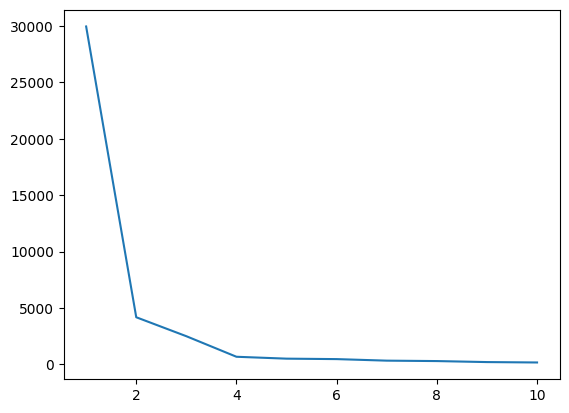

In [8]:
plt.plot(range(1,11),wcss)

In [9]:
X = df.iloc[:,:].values
km = KMeans(n_clusters=4)
y_means = km.fit_predict(X)

In [10]:
y_means

array([0, 3, 2, 2, 3, 3, 2, 1, 3, 2, 0, 3, 2, 0, 3, 2, 3, 2, 3, 3, 2, 0,
       2, 0, 0, 2, 0, 1, 2, 3, 1, 3, 1, 3, 2, 2, 1, 3, 0, 3, 0, 2, 2, 0,
       1, 1, 2, 3, 1, 3, 0, 0, 1, 2, 1, 3, 3, 1, 3, 1, 3, 2, 2, 1, 0, 1,
       2, 0, 3, 2, 3, 1, 2, 0, 3, 1, 3, 1, 0, 2, 2, 1, 3, 0, 1, 0, 1, 3,
       1, 3, 1, 1, 2, 0, 2, 2, 1, 2, 0, 1, 3, 0, 0, 1, 0, 0, 2, 0, 1, 1,
       2, 1, 3, 3, 2, 1, 2, 3, 1, 0, 0, 3, 2, 1, 2, 0, 2, 3, 0, 2, 2, 3,
       0, 0, 3, 1, 3, 0, 2, 2, 2, 0, 3, 0, 0, 1, 0, 1, 3, 0, 1, 0, 1, 1,
       0, 2, 3, 1, 3, 2, 0, 1, 3, 2, 1, 0, 3, 0, 0, 1, 1, 3, 1, 0, 0, 2,
       1, 3, 0, 1, 1, 3, 3, 3, 2, 0, 2, 2, 1, 3, 2, 2, 0, 0, 2, 0, 1, 3,
       3, 1], dtype=int32)

In [11]:
X[y_means == 3,1]

array([113., 110., 109., 110., 110., 108., 111., 111., 113., 106., 112.,
       106., 108., 113., 108., 109., 108., 111., 109., 104., 111., 109.,
       109., 112., 111., 109., 108., 110., 109., 111., 108., 109., 109.,
       111., 112., 109., 111., 107., 111., 110., 108., 109., 110., 108.,
       108., 110., 107., 111., 112., 108.])

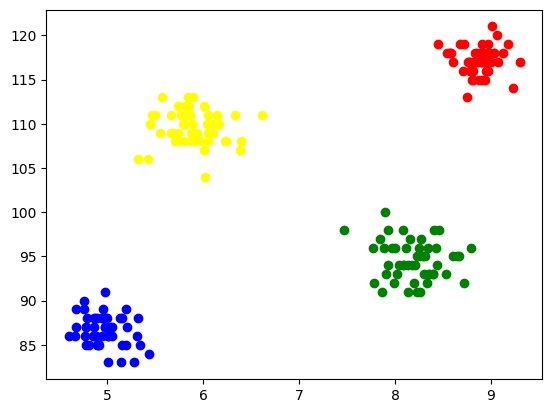

In [12]:
plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color='blue')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color='red')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color='green')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],color='yellow')

# K-Means on 3-D Data

In [13]:
from sklearn.datasets import make_blobs

centroids = [(-5,-5,5),(5,5,-5),(3.5,-2.5,4),(-2.5,2.5,-4)]
cluster_std = [1,1,1,1]

X,y = make_blobs(n_samples=200,cluster_std=cluster_std,centers=centroids,n_features=3,random_state=1)

In [ ]:
X

In [15]:
import plotly.express as px
fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=X[:,2])
fig.show()

In [16]:
wcss = []
for i in range(1,21):
    km = KMeans(n_clusters=i)
    km.fit_predict(X)
    wcss.append(km.inertia_)

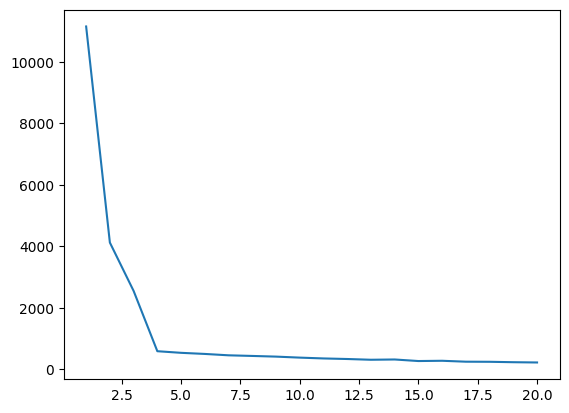

In [17]:
plt.plot(range(1,21),wcss)

In [18]:
km = KMeans(n_clusters=4)
y_pred = km.fit_predict(X)

In [19]:
df = pd.DataFrame()

df['col1'] = X[:,0]
df['col2'] = X[:,1]
df['col3'] = X[:,2]
df['label'] = y_pred

In [21]:
fig = px.scatter_3d(df,x='col1', y='col2', z='col3',color='label')
fig.show()

# K-Means Clustering Algorithm From Scratch

In [22]:
import random
import numpy as np

class KMeans:
    def __init__(self,n_clusters=2,max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def fit_predict(self,X):

        random_index = random.sample(range(0,X.shape[0]),self.n_clusters)
        self.centroids = X[random_index]

        for i in range(self.max_iter):
            # assign clusters
            cluster_group = self.assign_clusters(X)
            old_centroids = self.centroids
            # move centroids
            self.centroids = self.move_centroids(X,cluster_group)
            # check finish
            if (old_centroids == self.centroids).all():
                break

        return cluster_group

    def assign_clusters(self,X):
        cluster_group = []
        distances = []

        for row in X:
            for centroid in self.centroids:
                distances.append(np.sqrt(np.dot(row-centroid,row-centroid)))
            min_distance = min(distances)
            index_pos = distances.index(min_distance)
            cluster_group.append(index_pos)
            distances.clear()

        return np.array(cluster_group)

    def move_centroids(self,X,cluster_group):
        new_centroids = []

        cluster_type = np.unique(cluster_group)

        for type in cluster_type:
            new_centroids.append(X[cluster_group == type].mean(axis=0))

        return np.array(new_centroids)
